# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    try:
        X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"), dtype=np.float32)
        y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"), dtype=np.int32) - 1
        
        X_test  = np.loadtxt(os.path.join(root_dir, "test",  "X_test.txt"), dtype=np.float32)
        y_test  = np.loadtxt(os.path.join(root_dir, "test",  "y_test.txt"), dtype=np.int32) - 1

        return X_train, y_train, X_test, y_test
    except:
        raise Exception("Failed to load HAR test and training data.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",               #0
    "WALKING_UPSTAIRS",      #1
    "WALKING_DOWNSTAIRS",    #2
    "SITTING",               #3
    "STANDING",              #4
    "LAYING"                 #5
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#

num_features = 561
num_classes = 6


## 5. Quick Inspection


In [5]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#

print("Training set:", X_train.shape, y_train.shape)
print("Test set    :", X_test.shape, y_test.shape)
print("Input dtype :", X_train.dtype)
print("Label dtype :", y_train.dtype)

indices, counts = np.unique(y_train, return_counts=True)
print(" " * 48)
print("-" * 48)
print(f"{'Class Index':<12} | {'Class Name':<20} | {'# Samples':<8}")
print("-" * 48)

for ind, count in zip(indices, counts):
    print(f"{ind:<12} | {class_names[ind]:<20} | {count:<8}")

Training set: (7352, 561) (7352,)
Test set    : (2947, 561) (2947,)
Input dtype : float32
Label dtype : int32
                                                
------------------------------------------------
Class Index  | Class Name           | # Samples
------------------------------------------------
0            | WALKING              | 1226    
1            | WALKING_UPSTAIRS     | 1073    
2            | WALKING_DOWNSTAIRS   | 986     
3            | SITTING              | 1286    
4            | STANDING             | 1374    
5            | LAYING               | 1407    


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model
    

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0712 - accuracy: 0.9723 - val_loss: 0.2235 - val_accuracy: 0.9307
Epoch 7/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0588 - accuracy: 0.9776 - val_loss: 0.1442 - val_accuracy: 0.9422
Epoch 8/40
92/92 [==

### Training Curves


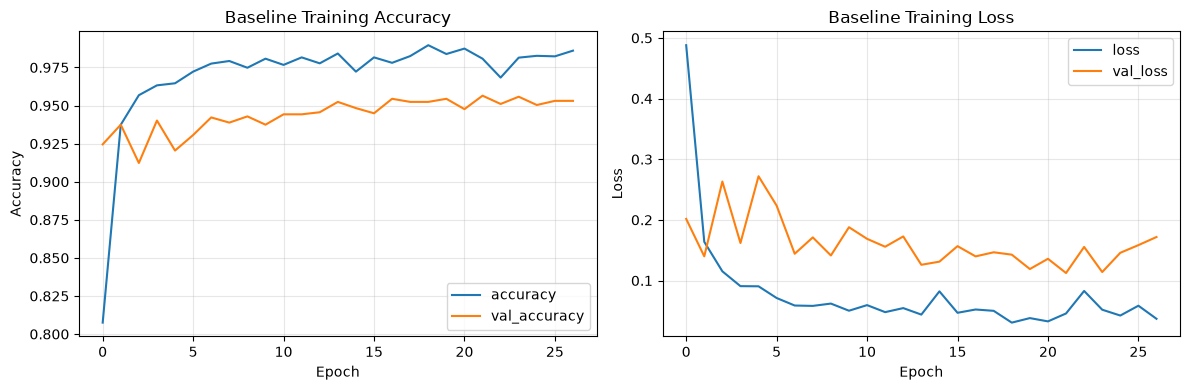

In [8]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#

history_df = pd.DataFrame(baseline_history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))


history_df[["accuracy", "val_accuracy"]].plot(ax=axes[0], title="Baseline Training Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)

history_df[["loss", "val_loss"]].plot(ax=axes[1], title="Baseline Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Evaluate the Baseline Keras Model


Baseline Test Accuracy: 0.9264

                    precision    recall  f1-score   support

           WALKING     0.8591    0.9960    0.9225       496
  WALKING_UPSTAIRS     0.9525    0.8514    0.8991       471
WALKING_DOWNSTAIRS     0.9721    0.9119    0.9410       420
           SITTING     0.9315    0.8859    0.9081       491
          STANDING     0.8724    0.9380    0.9040       532
            LAYING     1.0000    0.9646    0.9820       537

          accuracy                         0.9264      2947
         macro avg     0.9313    0.9246    0.9261      2947
      weighted avg     0.9303    0.9264    0.9265      2947



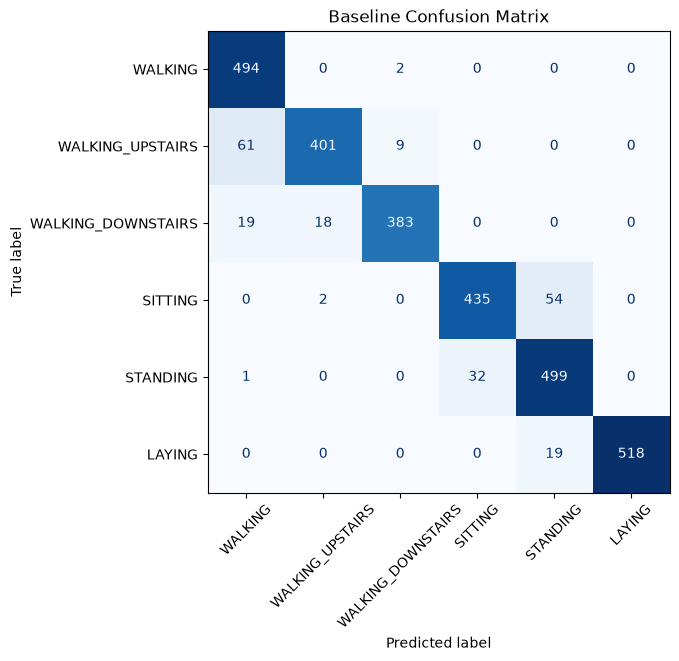

In [9]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


probs = baseline_model.predict(X_test, verbose=0)
preds = np.argmax(probs, axis=1)
test_acc = accuracy_score(y_test, preds)

print(f"Baseline Test Accuracy: {test_acc:.4f}\n")
print(classification_report(y_test, preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, preds),
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Confusion Matrix")
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    for i in range(300):
        yield [X_train[i:i+1].astype(np.float32)]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])


        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#
        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [11]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#


fp32_tflite_model = convert_to_tflite_fp32(baseline_model)
drq_tflite_model = convert_to_tflite_dynamic_range(baseline_model)
float16_tflite_model = convert_to_tflite_float16(baseline_model)
int8_tflite_model = convert_to_tflite_int8(baseline_model)

fp32_size_kb = save_binary_model(fp32_tflite_model, "baseline_fp32.tflite")
drq_size_kb = save_binary_model(drq_tflite_model, "baseline_dynamic_range.tflite")
float16_size_kb = save_binary_model(float16_tflite_model, "baseline_float16.tflite")
int8_size_kb = save_binary_model(int8_tflite_model, "baseline_int8.tflite")

fp32_acc, fp32_preds = evaluate_tflite_model(fp32_tflite_model, X_test, y_test)
drq_acc, drq_preds = evaluate_tflite_model(drq_tflite_model, X_test, y_test)
float16_acc, float16_preds = evaluate_tflite_model(float16_tflite_model, X_test, y_test)
int8_acc, int8_preds = evaluate_tflite_model(int8_tflite_model, X_test, y_test)


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmp6e8f9b73/assets


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmp6e8f9b73/assets


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpyqqyaikz/assets


2026-07-15 21:47:12.150925: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 21:47:12.150935: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 21:47:12.151078: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmp6e8f9b73
2026-07-15 21:47:12.151495: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 21:47:12.151499: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmp6e8f9b73
2026-07-15 21:47:12.152246: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-07-15 21:47:12.152614: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 21:47:12.169612: I tensorflow/cc/saved_model/loader.

INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpb8d6ojl6/assets


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpb8d6ojl6/assets


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpj112h8z2/assets


2026-07-15 21:47:12.629122: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 21:47:12.629131: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 21:47:12.629207: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpb8d6ojl6
2026-07-15 21:47:12.629551: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 21:47:12.629554: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpb8d6ojl6
2026-07-15 21:47:12.630440: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 21:47:12.645611: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpb8d6ojl6
2026-07-

## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#

def build_results_table(rows):
    df = pd.DataFrame(rows)
    df["size_kb"] = df["size_kb"].round(2)
    df["accuracy"] = df["accuracy"].round(6)
    return df

ptq_rows = []

for model_name, model_format, model_acc, model_size in [
    ("PTQ FP32", "FP32", fp32_acc, fp32_size_kb),
    ("PTQ Dynamic Range", "FP32", drq_acc, drq_size_kb),
    ("PTQ Float16", "FP16", float16_acc, float16_size_kb),
    ("PTQ INT8", "INT8", int8_acc, int8_size_kb),
]:
    ptq_rows.append(
        {
            "model family": model_name,
            "format": model_format,
            "accuracy": model_acc,
            "size_kb": model_size,
        }
    )

ptq_results = build_results_table(ptq_rows)
ptq_results



,model family,format,accuracy,size_kb
0,PTQ FP32,FP32,0.926366,726.72
1,PTQ Dynamic Range,FP32,0.926026,186.11
2,PTQ Float16,FP16,0.926366,365.71
3,PTQ INT8,INT8,0.925687,185.34


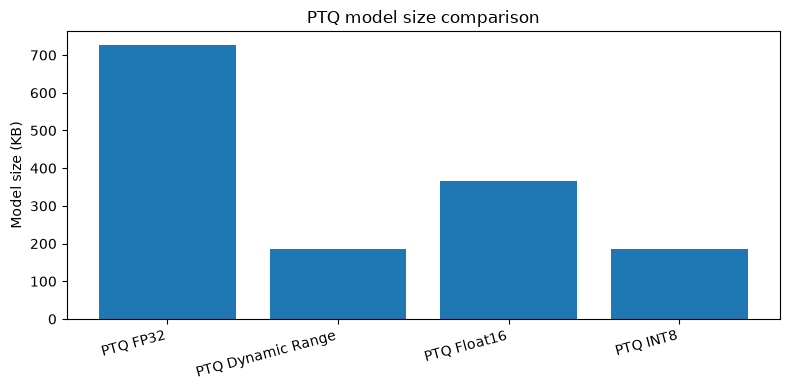

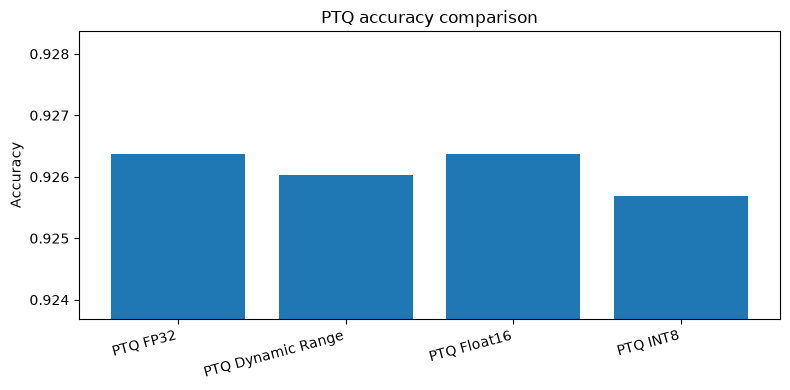

In [13]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#


ptq_plot_df = ptq_results.copy()

plt.figure(figsize=(8, 4))
plt.bar(ptq_plot_df["model family"], ptq_plot_df["size_kb"])
plt.ylabel("Model size (KB)")
plt.title("PTQ model size comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(ptq_plot_df["model family"], ptq_plot_df["accuracy"])
plt.ylabel("Accuracy")
plt.ylim(max(0.0, ptq_plot_df["accuracy"].min() - 0.002), min(1.0, ptq_plot_df["accuracy"].max() + 0.002))
plt.title("PTQ accuracy comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


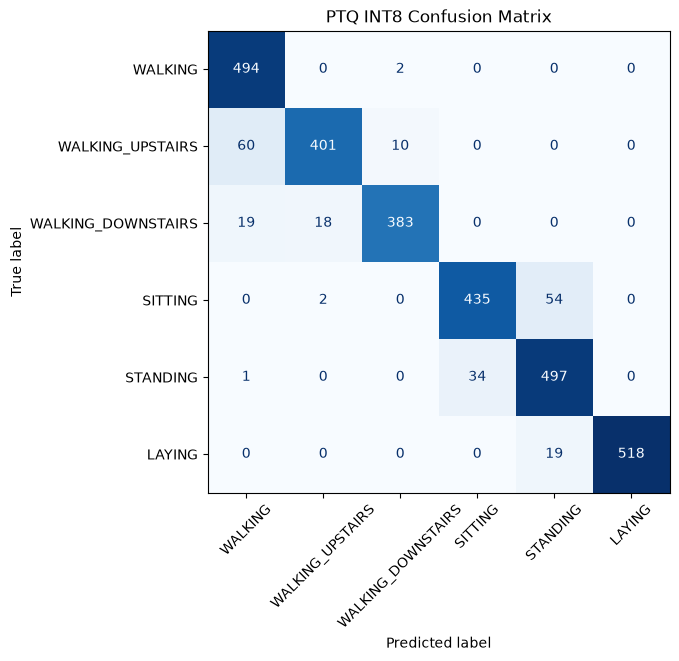

PTQ INT8 Test Accuracy: 0.9257

                    precision    recall  f1-score   support

           WALKING     0.8606    0.9960    0.9234       496
  WALKING_UPSTAIRS     0.9525    0.8514    0.8991       471
WALKING_DOWNSTAIRS     0.9696    0.9119    0.9399       420
           SITTING     0.9275    0.8859    0.9062       491
          STANDING     0.8719    0.9342    0.9020       532
            LAYING     1.0000    0.9646    0.9820       537

          accuracy                         0.9257      2947
         macro avg     0.9304    0.9240    0.9254      2947
      weighted avg     0.9294    0.9257    0.9258      2947



In [14]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, int8_preds),
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("PTQ INT8 Confusion Matrix")
plt.show()


print(f"PTQ INT8 Test Accuracy: {int8_acc:.4f}\n")
print(classification_report(y_test, int8_preds, target_names=class_names, digits=4))


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Fine-Tune the QAT Model


In [16]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#

qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)

Epoch 1/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0283 - accuracy: 0.9917 - val_loss: 0.1256 - val_accuracy: 0.9579
Epoch 2/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0236 - accuracy: 0.9915 - val_loss: 0.1253 - val_accuracy: 0.9585
Epoch 3/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0223 - accuracy: 0.9929 - val_loss: 0.1286 - val_accuracy: 0.9572
Epoch 4/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0207 - accuracy: 0.9929 - val_loss: 0.1269 - val_accuracy: 0.9579
Epoch 5/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0195 - accuracy: 0.9935 - val_loss: 0.1533 - val_accuracy: 0.9551
Epoch 6/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0215 - accuracy: 0.9920 - val_loss: 0.1419 - val_accuracy: 0.9572
Epoch 7/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0190 - accuracy: 0.9932 - val_loss: 0.1332 - val_accuracy: 0.9585
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


QAT Test Accuracy: 0.9362

                    precision    recall  f1-score   support

           WALKING     0.9326    0.9758    0.9537       496
  WALKING_UPSTAIRS     0.9237    0.9257    0.9247       471
WALKING_DOWNSTAIRS     0.9674    0.9190    0.9426       420
           SITTING     0.9596    0.8697    0.9124       491
          STANDING     0.8567    0.9662    0.9081       532
            LAYING     1.0000    0.9534    0.9762       537

          accuracy                         0.9362      2947
         macro avg     0.9400    0.9350    0.9363      2947
      weighted avg     0.9392    0.9362    0.9365      2947



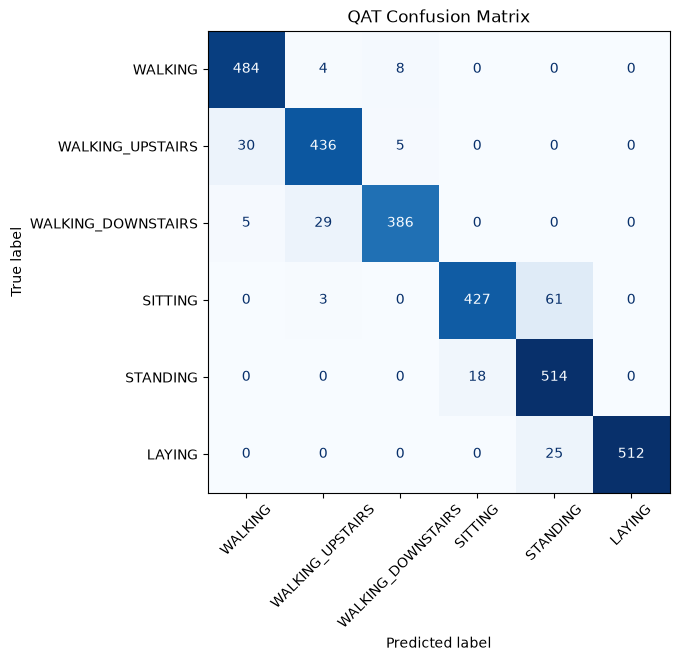

In [17]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


qat_probs = qat_model.predict(X_test, verbose=0)
qat_preds = np.argmax(qat_probs, axis=1)
qat_test_acc = accuracy_score(y_test, qat_preds)

print(f"QAT Test Accuracy: {qat_test_acc:.4f}\n")
print(classification_report(y_test, qat_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, qat_preds),
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("QAT Confusion Matrix")
plt.show()


### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#

int8_qat_tflite_model = convert_to_tflite_int8(qat_model)
int8_qat_size_kb = save_binary_model(int8_qat_tflite_model, "qat_int8.tflite")
int8_qat_acc, int8_qat_preds = evaluate_tflite_model(int8_qat_tflite_model, X_test, y_test)


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmp7r7j5g3t/assets


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmp7r7j5g3t/assets
/Users/eauvero/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-15 21:47:15.557110: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 21:47:15.557119: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 21:47:15.557188: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmp7r7j5g3t
2026-07-15 21:47:15.557980: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 21:47:15.557984: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/sj/5nvjkzpd2133t

## 12. PTQ Int8 vs QAT Int8


In [19]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#


ptq_qat_rows = []

for model_name, model_format, model_acc, model_size in [
    ("PTQ INT8", "INT8", int8_acc, int8_size_kb),
    ("QAT INT8", "INT8", int8_qat_acc, int8_qat_size_kb),
]:
    ptq_qat_rows.append(
        {
            "model family": model_name,
            "format": model_format,
            "accuracy": model_acc,
            "size_kb": model_size,
        }
    )

ptq_qat_results = build_results_table(ptq_qat_rows)
ptq_qat_results


,model family,format,accuracy,size_kb
0,PTQ INT8,INT8,0.925687,185.34
1,QAT INT8,INT8,0.936206,185.70


QAT INT8 Test Accuracy: 0.9362

                    precision    recall  f1-score   support

           WALKING     0.9326    0.9758    0.9537       496
  WALKING_UPSTAIRS     0.9237    0.9257    0.9247       471
WALKING_DOWNSTAIRS     0.9674    0.9190    0.9426       420
           SITTING     0.9596    0.8697    0.9124       491
          STANDING     0.8567    0.9662    0.9081       532
            LAYING     1.0000    0.9534    0.9762       537

          accuracy                         0.9362      2947
         macro avg     0.9400    0.9350    0.9363      2947
      weighted avg     0.9392    0.9362    0.9365      2947



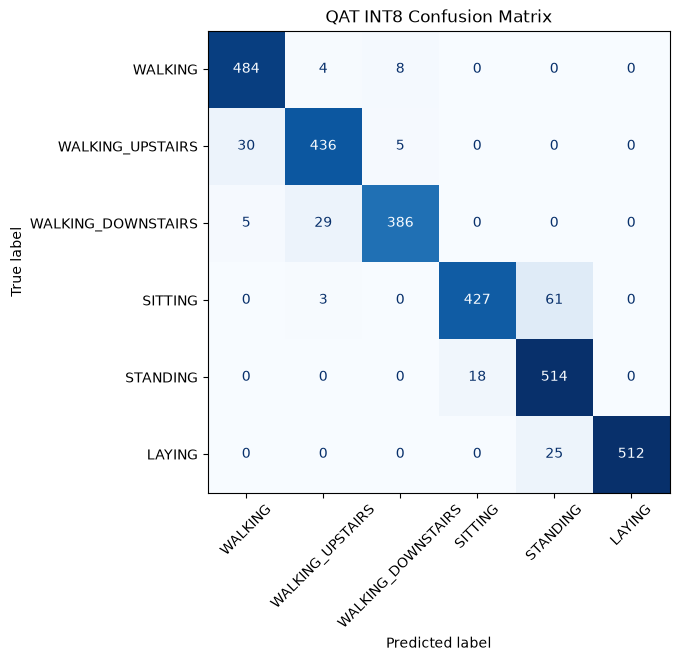

In [20]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"QAT INT8 Test Accuracy: {int8_qat_acc:.4f}\n")
print(classification_report(y_test, int8_qat_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, int8_qat_preds),
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("QAT INT8 Confusion Matrix")
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?

Post-training Quantization with INT8 produced the smallest model size at 185.34kb

2. Which quantization method gave the best accuracy among the TensorFlow Lite models?

Quantization-aware training gave the best accuracy at 0.9362.

3. Did QAT improve the final int8 model compared with PTQ int8?

QAT INT8 was more accurate with 0.9362 accuracy. PTQ INT8 had a 0.9257 accuracy.  

4. Why is this dataset a good fit for a DNN-based TinyML workflow?

This dataset had plenty of features to work with (561 features). There were also plenty of data points to train with and each of the 6 output classes appeared roughly in the same proportion in the training dataset. 

5. If you were deploying this model on a resource-constrained device, which version would you choose and why?

I would deploy the QAT INT8 model. It has the greatest accuracy score at 0.9362 and it's only 185.70kb. The extra 0.36kb compared to PTQ INT8 is worth the tradeoff for an extra 0.0105 accuracy.   


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
